In [ ]:
# !unzip PySESM.zip
# !pip install torchmetrics

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal
from torchmetrics import MeanSquaredError, Accuracy, Precision, Recall, F1Score
from sklearn.model_selection import RandomizedSearchCV

from PySESM.models.SESM.SESM import SESM_Model
from PySESM.base_functions.Function import GaussianFunctions


In [ ]:
N_points = 50
xl = -2
xr = 2

x = np.linspace(xl, xr, N_points)
xx, yy = np.meshgrid(x, x)
X = np.column_stack([xx.ravel(), yy.ravel()])

In [ ]:

# Convert NumPy arrays to PyTorch tensors with data type float32
e0 = torch.tensor([1.0, 1.0], dtype=torch.float32)
e0 = e0 / e0.norm()

#------------------1st gaussian
rotation_matrix_1 = torch.tensor([[np.cos(np.pi/2), -np.sin(np.pi/4)],
                            [np.sin(np.pi/4), np.cos(np.pi/2)]], dtype=torch.float32)
e1 = torch.mm(rotation_matrix_1, e0.unsqueeze(1))

E = torch.cat((e0.unsqueeze(1), e1), dim=1)

D = torch.diag(torch.tensor([0.4, 0.1], dtype=torch.float32))
sigma1 = torch.mm(torch.mm(E, D), E.t())

#-------------------2nd gaussian
rotation_matrix_2 = torch.tensor([[np.cos(np.pi/2), -np.sin(np.pi/4)],
                            [np.sin(np.pi/4), np.cos(np.pi/2)]], dtype=torch.float32)
e2 = torch.mm(rotation_matrix_2, e0.unsqueeze(1))

E2 = torch.cat((e0.unsqueeze(1), e2), dim=1)

D2 = 0.5 * torch.diag(torch.tensor([0.05, 0.5], dtype=torch.float32))
sigma2 = torch.mm(torch.mm(E2, D2), E2.t())

#-------------------3rd gaussian
rotation_matrix_3 = torch.tensor([[np.cos(np.pi/2), -np.sin(np.pi/4)],
                            [np.sin(np.pi/4), np.cos(np.pi/2)]], dtype=torch.float32)
e3 = torch.mm(rotation_matrix_3, e0.unsqueeze(1))

E3 = torch.cat((e0.unsqueeze(1), e3), dim=1)

D3 = 0.7 * torch.diag(torch.tensor([0.05, 0.5], dtype=torch.float32))
sigma3 = torch.mm(torch.mm(E3, D3), E3.t())

mu1 = torch.tensor([1, 1], dtype=torch.float32)
mu2 = torch.tensor([-1, -1], dtype=torch.float32)
mu3 = torch.tensor([1, -1], dtype=torch.float32)

x = np.linspace(-2, 2, 51)
xx, yy = np.meshgrid(x, x)
X = torch.tensor(np.column_stack([xx.ravel(), yy.ravel()]), dtype=torch.float32)

z1 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu1.numpy(), sigma1.numpy()), dtype=torch.float32)
z2 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu2.numpy(), sigma2.numpy()), dtype=torch.float32)
z3 = torch.tensor(multivariate_normal.pdf(X.numpy(), mu3.numpy(), sigma3.numpy()), dtype=torch.float32)

zz = (z1 + z2 + z3).reshape(xx.shape)

fig = go.Figure(data=[go.Surface(z=zz.numpy(), x=xx, y=yy)])
fig.update_layout(scene=dict(aspectmode='data'))
fig.update_layout(scene=dict(camera=dict(eye=dict(x=2, y=2, z=1))))

fig.show()


In [ ]:
x_values = xx.ravel()
y_values = yy.ravel()
z_values = zz.ravel()

n_samples = 50
n_features = 2
l_functions =  20

In [ ]:
total_points = len(x_values)

min_separation = 20

selected_indexes = []

while len(selected_indexes) < n_samples:

    random_index = np.random.randint(total_points)

    if all(abs(random_index - existing_index) >= min_separation for existing_index in selected_indexes):
        selected_indexes.append(random_index)

sampled_indices = selected_indexes

sampled_x = torch.tensor(x_values[sampled_indices], dtype=torch.float32)
sampled_y = torch.tensor(y_values[sampled_indices], dtype=torch.float32)

X = torch.stack((sampled_x, sampled_y), dim=1)
y = z_values[sampled_indices].clone().detach().to(dtype=torch.float32)


In [ ]:
gaussian_function = GaussianFunctions(n_features= n_features, n_functions = l_functions)

In [ ]:
model = SESM_Model(
    n_samples=n_samples,
    n_features=n_features,
    n_functions=l_functions,
    psi=gaussian_function.gaussian
)

In [ ]:
# # Define a distribution of hyperparameter values
# param_dist = {
#     'ista_alpha': [0.01, 0.05, 0.1],
#     'ista_lambd': [0.001, 0.005, 0.01],
#     'dictionary_alpha': [0.01, 0.05, 0.1]
# }

# # Create the randomized search object
# randomized_search = RandomizedSearchCV(model, param_dist, n_iter=10, cv=5, n_jobs=-1)

# # Fit the model with different hyperparameters
# randomized_search.fit(X, y)

# # Get the best hyperparameters
# best_params = randomized_search.best_params_

In [ ]:
model_epochs = 100
ista_epochs = 500
dictionary_epochs = 200

ista_alpha = 0.06
ista_lambd = 0.005

dictionary_alpha = 0.06

model.fit(
    X=X,
    y=y,
    model_epochs=model_epochs,
    ista_epochs=ista_epochs,
    ista_alpha=ista_alpha,
    ista_lambd=ista_lambd,
    dictionary_epochs=dictionary_epochs,
    dictionary_alpha=dictionary_alpha
)


Training sparse vector: 100%|██████████| 500/500 [00:00<00:00, 1845.13it/s]

Training model:   1%|          | 1/100 [00:00<01:28,  1.11it/s]

Epoch 1 Loss: 0.14531929790973663




Training sparse vector: 100%|██████████| 500/500 [00:00<00:00, 682.59it/s]

Training model:   2%|▏         | 2/100 [00:02<01:51,  1.13s/it]

Epoch 2 Loss: 0.07953579723834991




Training sparse vector: 100%|██████████| 500/500 [00:00<00:00, 742.30it/s]

Training model:   3%|▎         | 3/100 [00:03<01:54,  1.18s/it]

...

Epoch 98 Loss: 0.025197811424732208




Training sparse vector: 100%|██████████| 500/500 [00:00<00:00, 663.33it/s]

Training model:  99%|█████████▉| 99/100 [02:16<00:01,  1.35s/it]

Epoch 99 Loss: 0.02519788220524788




Training sparse vector: 100%|██████████| 500/500 [00:00<00:00, 648.92it/s]

Training model: 100%|██████████| 100/100 [02:17<00:00,  1.37s/it]

Epoch 100 Loss: 0.025197869166731834



In [ ]:
x_tensor = torch.tensor(x_values)
y_tensor = torch.tensor(y_values)
XY = torch.cat((x_tensor.unsqueeze(1), y_tensor.unsqueeze(1)), dim=1)

Z = model.predict(XY)

print(f'Duración del modelo: {model.time / 60:.2f} minutos')

Duración del modelo: 2.29 minutos


<ipython-input-26-f1bc8c9acb30>:26: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

<ipython-input-26-f1bc8c9acb30>:27: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



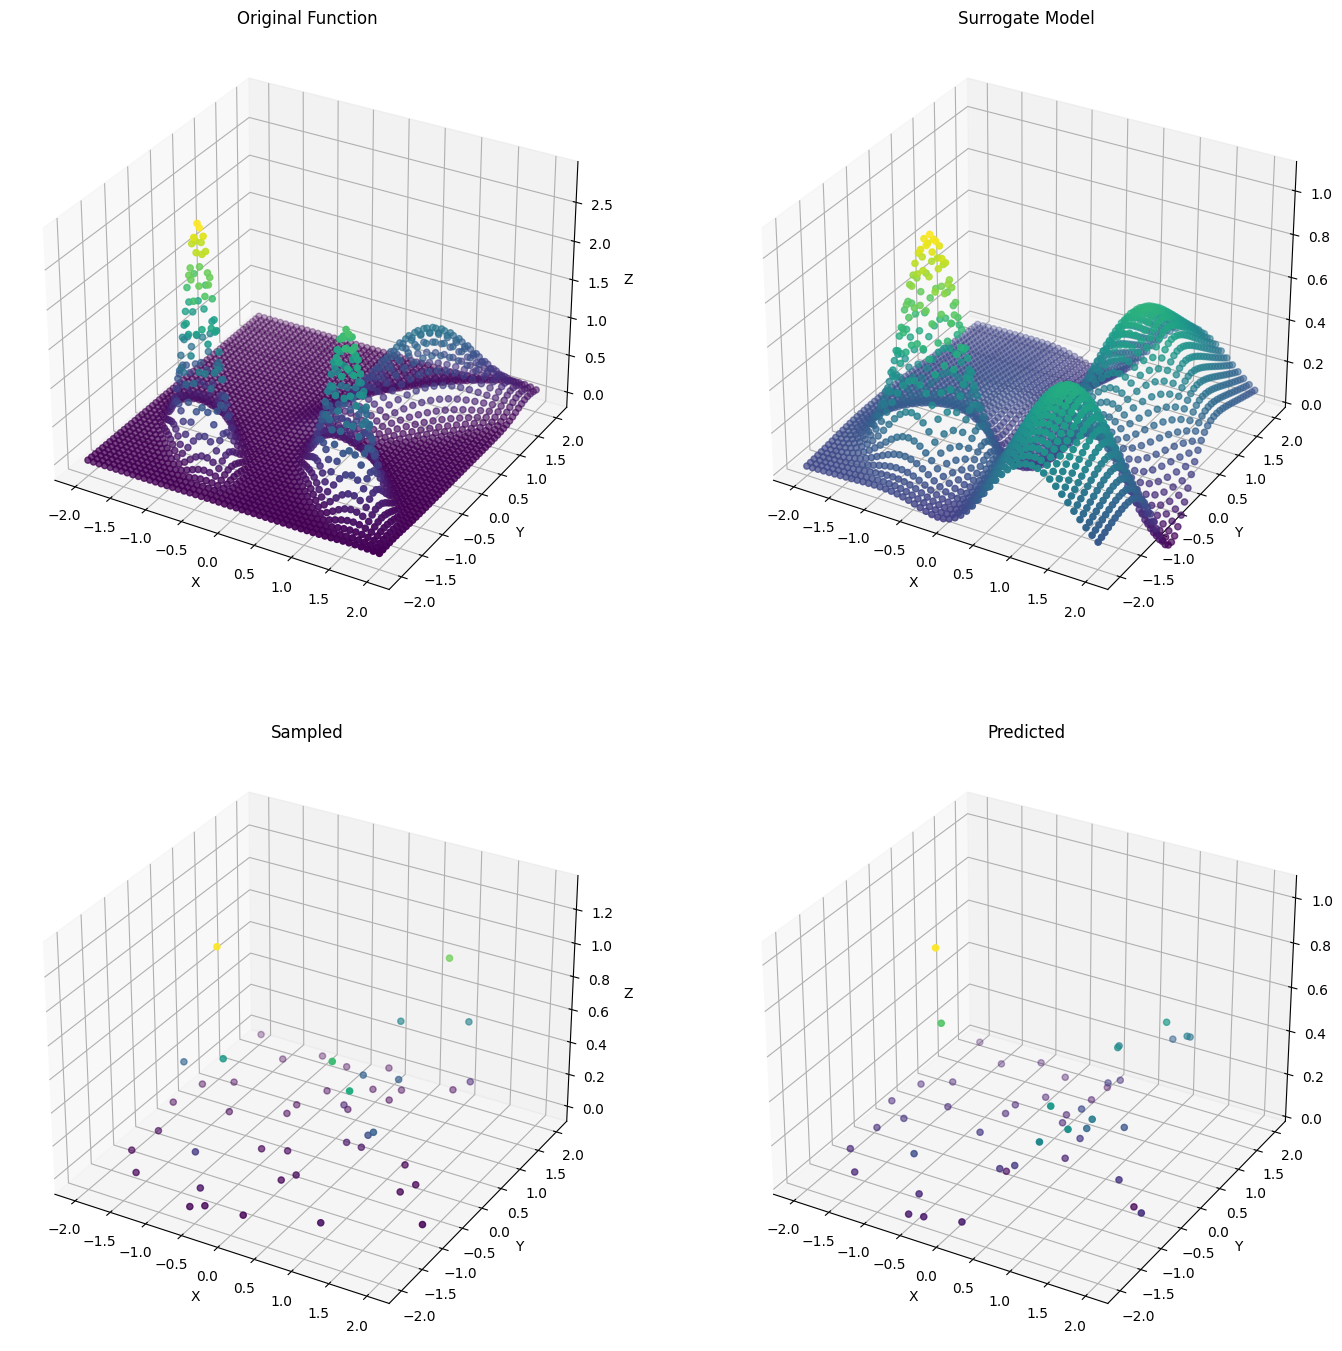

In [ ]:
fig = plt.figure(figsize=(17, 17))

ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(x_values, y_values, z_values,c=z_values)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Original Function')


ax2 = fig.add_subplot(222, projection='3d')
ax2.scatter(x_values, y_values, Z.detach(), c=Z.detach())
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Surrogate Model')
ax2.set_zlim(0)

ax3 = fig.add_subplot(223, projection='3d')
ax3.scatter(sampled_x, sampled_y, y,c=y)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Sampled')

xs_tensor = torch.tensor(sampled_x)
ys_tensor = torch.tensor(sampled_y)
XYs = torch.cat((xs_tensor.unsqueeze(1), ys_tensor.unsqueeze(1)), dim=1)
zp = model.predict(XYs).detach()
ax4 = fig.add_subplot(224, projection='3d')
ax4.scatter(sampled_x, sampled_y, zp,c=zp)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.set_title('Predicted')
ax4.set_zlim(0)



# Show the plot
plt.show()

Text(0.5, 0, 'Iteration')

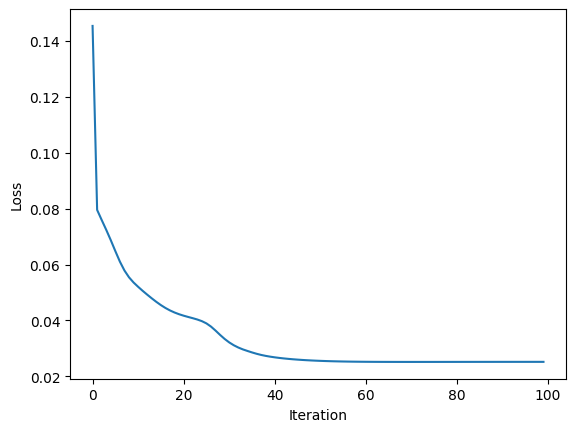

In [ ]:
plt.plot(model.losses)

plt.ylabel('Loss')
plt.xlabel('Iteration')


In [ ]:
# Init MSE metric
mse = MeanSquaredError()
# Compute MSE
mse(zp, y)
mse_value = mse.compute()
print('MSE:', mse_value)

MSE: tensor(0.0252)
